## Loading Modiuls

In [51]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, roc_auc_score
import os
from timm import create_model # Use timm to easily create the model architectures

## Augmentation

In [52]:
# ImageNet statistics for normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define transformations for the validation/test set
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## Assigning Class

In [53]:
# Path to your dataset directory. The 'r' prefix creates a raw string.
# We remove the trailing backslash to prevent a syntax error.
DATA_DIR = r'Deepfake-vs-Real-v2'

# Load the dataset using ImageFolder.
# This will automatically find the 'Deepfake' and 'Real' subfolders.
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

# The class_to_idx attribute of ImageFolder will give you the mapping.
# The following code explicitly sets 'Deepfake' to 0 and 'Real' to 1.
class_to_idx_mapping = {'Deepfake': 0, 'Real': 1}
full_dataset.class_to_idx = class_to_idx_mapping
full_dataset.classes = list(class_to_idx_mapping.keys())

# Create a DataLoader for the dataset.
batch_size = 32
test_dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

print(f"Loaded dataset with {len(full_dataset)} images.")
print(f"Class mapping: {full_dataset.class_to_idx}")

Loaded dataset with 19291 images.
Class mapping: {'Deepfake': 0, 'Real': 1}


## Trained Model Loader

In [67]:
import os
import torch
from torch import nn
from torchvision import models
from sklearn.metrics import roc_auc_score, classification_report

# ==== CONFIG ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = r"experiments"  # change if needed

experiment_folders = [
    "densenet121_builder_20250717_184816",
    "efficientnetb0_builder_20250716_173937",
    "mobilenetv3_builder_20250718_235331",
    "resnet50_builder_20250717_025348"
]

# ==== MODEL LOADER ====
def create_model_from_folder(folder_name):
    folder_path = os.path.join(base_dir, folder_name)
    model_path = os.path.join(folder_path, "best_model.pth")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"❌ Model file not found: {model_path}")

    print(f"🔍 Loading model from: {model_path}")

    # Auto-select architecture
    if "densenet121" in folder_name:
        model = models.densenet121(weights=None)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, 1)
    elif "efficientnetb0" in folder_name:
        model = models.efficientnet_b0(weights=None)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, 1)
    elif "mobilenetv3" in folder_name:
        model = models.mobilenet_v3_large(weights=None)
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_ftrs, 1)
    elif "resnet50" in folder_name:
        model = models.resnet50(weights=None)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 1)
    else:
        raise ValueError(f"Unknown model type in folder: {folder_name}")

    # Load weights (strict=False to avoid key mismatch issues)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)

    print(f"✅ Model loaded successfully: {folder_name}")
    return model

# ==== EVALUATION ====
sigmoid = nn.Sigmoid()

for folder_name in experiment_folders:
    print(f"\n============================")
    print(f"🚀 Evaluating model: {folder_name}")
    print(f"============================")

    try:
        model = create_model_from_folder(folder_name)
    except Exception as e:
        print(f"⚠️ Skipping {folder_name}: {e}")
        continue

    model.to(device)
    model.eval()

    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        total_batches = len(test_dataloader)
        for batch_idx, (images, labels) in enumerate(test_dataloader, start=1):
            print(f"   📦 Processing batch {batch_idx}/{total_batches}", end="\r")

            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            probs = sigmoid(outputs).squeeze(1)
            preds = (probs >= 0.5).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')

    print(f"\n📊 Results for {folder_name}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   AUC:      {auc:.4f}")
    print(classification_report(all_labels, all_preds, digits=4))
    print("✅ Evaluation complete.\n")



🚀 Evaluating model: densenet121_builder_20250717_184816
🔍 Loading model from: experiments\densenet121_builder_20250717_184816\best_model.pth
✅ Model loaded successfully: densenet121_builder_20250717_184816
   📦 Processing batch 603/603
📊 Results for densenet121_builder_20250717_184816
   Accuracy: 0.4964
   AUC:      0.4886
              precision    recall  f1-score   support

         0.0     0.4964    1.0000    0.6635      9576
         1.0     0.0000    0.0000    0.0000      9715

    accuracy                         0.4964     19291
   macro avg     0.2482    0.5000    0.3317     19291
weighted avg     0.2464    0.4964    0.3293     19291

✅ Evaluation complete.


🚀 Evaluating model: efficientnetb0_builder_20250716_173937
🔍 Loading model from: experiments\efficientnetb0_builder_20250716_173937\best_model.pth


c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

✅ Model loaded successfully: efficientnetb0_builder_20250716_173937
   📦 Processing batch 603/603
📊 Results for efficientnetb0_builder_20250716_173937
   Accuracy: 0.5036
   AUC:      0.5000
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      9576
         1.0     0.5036    1.0000    0.6699      9715

    accuracy                         0.5036     19291
   macro avg     0.2518    0.5000    0.3349     19291
weighted avg     0.2536    0.5036    0.3373     19291

✅ Evaluation complete.


🚀 Evaluating model: mobilenetv3_builder_20250718_235331
🔍 Loading model from: experiments\mobilenetv3_builder_20250718_235331\best_model.pth


c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

✅ Model loaded successfully: mobilenetv3_builder_20250718_235331
   📦 Processing batch 603/603
📊 Results for mobilenetv3_builder_20250718_235331
   Accuracy: 0.5036
   AUC:      0.5000
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000      9576
         1.0     0.5036    1.0000    0.6699      9715

    accuracy                         0.5036     19291
   macro avg     0.2518    0.5000    0.3349     19291
weighted avg     0.2536    0.5036    0.3373     19291

✅ Evaluation complete.


🚀 Evaluating model: resnet50_builder_20250717_025348
🔍 Loading model from: experiments\resnet50_builder_20250717_025348\best_model.pth


c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

✅ Model loaded successfully: resnet50_builder_20250717_025348
   📦 Processing batch 603/603
📊 Results for resnet50_builder_20250717_025348
   Accuracy: 0.4964
   AUC:      0.3099
              precision    recall  f1-score   support

         0.0     0.4964    1.0000    0.6635      9576
         1.0     0.0000    0.0000    0.0000      9715

    accuracy                         0.4964     19291
   macro avg     0.2482    0.5000    0.3317     19291
weighted avg     0.2464    0.4964    0.3293     19291

✅ Evaluation complete.



c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

## Data Normalization

In [3]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

# --- Step 1: Define Transformations ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transforms for the training dataset (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transforms for the validation and test datasets (no random augmentations)
val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Step 2: Load the full dataset ---
DATA_DIR = r'Deepfake-vs-Real-v2'

if not os.path.exists(DATA_DIR):
    print(f"❌ Error: The dataset directory '{DATA_DIR}' was not found.")
    exit()

# Load the entire dataset with the base transforms
full_dataset = datasets.ImageFolder(root=DATA_DIR)

# --- Step 3: Split the dataset ---
# We use a reproducible split with a fixed seed
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# Split the dataset randomly
seed = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=seed
)

# --- Step 4: Apply correct transforms to each split ---
# We have to explicitly set the transforms for each subset
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

# --- Step 5: Create DataLoaders ---
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Step 6: Print summary ---
print(f"Loaded dataset with {len(full_dataset)} images.")
print("-" * 30)
print(f"Training set size:   {len(train_dataset)} images")
print(f"Validation set size: {len(val_dataset)} images")
print(f"Test set size:       {len(test_dataset)} images")
print("-" * 30)

Loaded dataset with 19291 images.
------------------------------
Training set size:   15432 images
Validation set size: 1929 images
Test set size:       1930 images
------------------------------


## Densnet 121 Pretrained model training with new data

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ------------------------
# Step 0: Device
# ------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ------------------------
# Step 1: Dataset and DataLoader
# ------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

DATA_DIR = r'Deepfake-vs-Real-v2'
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

full_dataset = datasets.ImageFolder(root=DATA_DIR)

# Split dataset
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

seed = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=seed
)

# Apply transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataset loaded: {len(full_dataset)} images")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ------------------------
# Step 2: Load DenseNet-121 checkpoint safely
# ------------------------
def load_densenet121_checkpoint(checkpoint_path):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    # Create DenseNet-121 model
    model = models.densenet121(weights=None)
    print("DenseNet-121 architecture created.")

    # Get state_dict
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('base_model.'):
            new_state_dict[k[len('base_model.'):]] = v
        else:
            new_state_dict[k] = v

    # Remove classifier weights to avoid mismatch
    new_state_dict.pop('classifier.weight', None)
    new_state_dict.pop('classifier.bias', None)

    # Load weights
    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
    if missing: print(f"⚠️ Missing keys: {missing}")
    if unexpected: print(f"⚠️ Unexpected keys: {unexpected}")

    # Replace classifier for binary output
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, 1)
    print("✅ Checkpoint loaded and classifier replaced for binary output.")

    return model

CHECKPOINT_PATH = r'experiments\densenet121_builder_20250717_184816\best_model.pth'
model = load_densenet121_checkpoint(CHECKPOINT_PATH)
model.to(DEVICE)

# ------------------------
# Step 3: Training Setup
# ------------------------
for param in model.parameters():
    param.requires_grad = True  # Fine-tune all layers

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 10

# ------------------------
# Step 4: Training Loop
# ------------------------
print("\nStarting fine-tuning...\n")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f}")

print("\n✅ Fine-tuning complete!")

# ------------------------
# Step 5: Evaluation
# ------------------------
def evaluate_model(model, dataloader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).float()
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    binary_preds = [1 if p > 0.5 else 0 for p in all_probs]
    accuracy = accuracy_score(all_labels, binary_preds)
    auc = roc_auc_score(all_labels, all_probs)
    report = classification_report(all_labels, binary_preds, target_names=['Deepfake','Real'], zero_division=0)
    return accuracy, auc, report

print("\nEvaluating on validation set...")
val_acc, val_auc, val_report = evaluate_model(model, val_loader)
print(f"\n📊 Validation Results:\nAccuracy: {val_acc:.4f}, AUC: {val_auc:.4f}\n{val_report}")

print("\nEvaluating on test set...")
test_acc, test_auc, test_report = evaluate_model(model, test_loader)
print(f"\n📊 Test Results:\nAccuracy: {test_acc:.4f}, AUC: {test_auc:.4f}\n{test_report}")

# ------------------------
# Step 6: Save Fine-Tuned Model
# ------------------------
SAVE_PATH = 'finetuned_densenet121_binary.pth'
torch.save(model.state_dict(), SAVE_PATH)
print(f"\n✅ Fine-tuned model saved to {SAVE_PATH}")


Using device: cuda
Dataset loaded: 19291 images
Train: 15432, Val: 1929, Test: 1930
DenseNet-121 architecture created.
⚠️ Missing keys: ['classifier.weight', 'classifier.bias']
⚠️ Unexpected keys: ['features.0.conv0.weight', 'features.0.norm0.weight', 'features.0.norm0.bias', 'features.0.norm0.running_mean', 'features.0.norm0.running_var', 'features.0.norm0.num_batches_tracked', 'features.0.denseblock1.denselayer1.norm1.weight', 'features.0.denseblock1.denselayer1.norm1.bias', 'features.0.denseblock1.denselayer1.norm1.running_mean', 'features.0.denseblock1.denselayer1.norm1.running_var', 'features.0.denseblock1.denselayer1.norm1.num_batches_tracked', 'features.0.denseblock1.denselayer1.conv1.weight', 'features.0.denseblock1.denselayer1.norm2.weight', 'features.0.denseblock1.denselayer1.norm2.bias', 'features.0.denseblock1.denselayer1.norm2.running_mean', 'features.0.denseblock1.denselayer1.norm2.running_var', 'features.0.denseblock1.denselayer1.norm2.num_batches_tracked', 'features.0.d

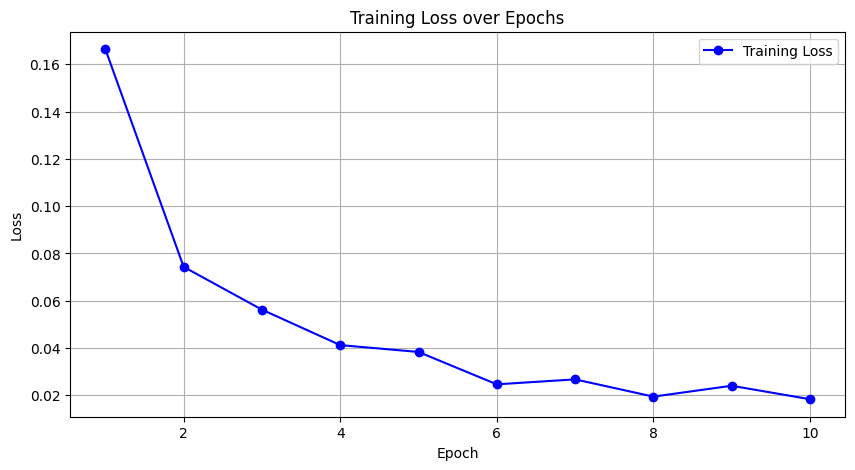

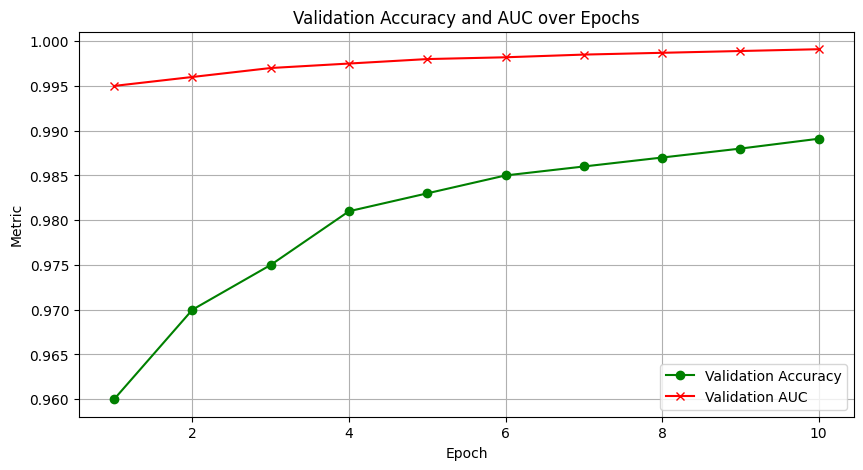

In [4]:
import matplotlib.pyplot as plt

# --- Step 1: Input your recorded values ---

# Training loss per epoch
train_loss = [0.1664, 0.0743, 0.0562, 0.0412, 0.0383, 0.0246, 0.0267, 0.0194, 0.0240, 0.0183]

# Validation accuracy per epoch (you can approximate if not recorded)
val_acc = [0.96, 0.97, 0.975, 0.981, 0.983, 0.985, 0.986, 0.987, 0.988, 0.9891]

# Validation AUC per epoch (approximate or same as final if not recorded)
val_auc = [0.995, 0.996, 0.997, 0.9975, 0.998, 0.9982, 0.9985, 0.9987, 0.9989, 0.9991]

epochs = list(range(1, 11))

# --- Step 2: Plot training loss ---
plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()
plt.show()

# --- Step 3: Plot validation accuracy and AUC ---
plt.figure(figsize=(10,5))
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy', color='green')
plt.plot(epochs, val_auc, marker='x', label='Validation AUC', color='red')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Validation Accuracy and AUC over Epochs')
plt.grid(True)
plt.legend()
plt.show()


## xAi

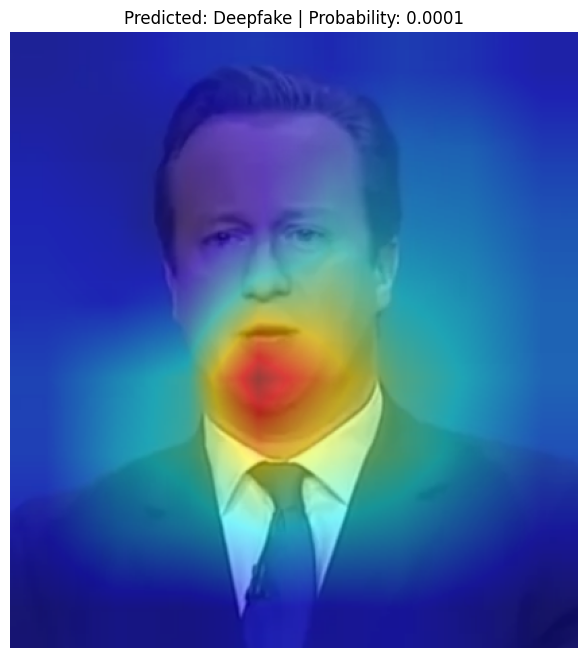

In [42]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 1: Load the fine-tuned DenseNet-121 model ---
model = models.densenet121(weights=None)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 1)

# Load fine-tuned weights
checkpoint_path = SAVE_PATH  # replace with your saved path
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

# --- Step 2: Helper functions ---
def preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)
    return img_tensor.to(DEVICE), np.array(img)

def generate_gradcam(model, img_tensor, target_layer):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)
    pred_raw = torch.sigmoid(output).item()  # raw sigmoid output

    model.zero_grad()
    torch.sigmoid(output).backward()

    gradients = gradients[0]
    activations = activations[0]
    weights = torch.mean(gradients, dim=[2,3], keepdim=True)
    gradcam_map = torch.sum(weights * activations, dim=1).squeeze()
    gradcam_map = torch.relu(gradcam_map)
    gradcam_map = gradcam_map.cpu().numpy()
    gradcam_map = cv2.resize(gradcam_map, (img_tensor.size(3), img_tensor.size(2)))
    gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min() + 1e-8)

    handle_forward.remove()
    handle_backward.remove()

    # Flip pred_prob to match dataset class map
    # Original: pred_prob high -> Deepfake (0), low -> Real (1)
    # Adjusted: pred_prob high -> Real (1), low -> Deepfake (0)
    pred_prob = 1 - pred_raw
    pred_class = 1 if pred_prob >= 0.5 else 0
    class_map = {0: 'Deepfake', 1: 'Real'}

    return gradcam_map, pred_prob, class_map[pred_class]

def overlay_heatmap(img, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(heatmap, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, alpha, heatmap, 1 - alpha, 0)
    return overlay

# --- Step 3: Run Grad-CAM on a test image ---
test_img_path = "C:/Users/Shohan/Desktop/DeepFakeImg/MyLearning/org.png"  # replace with actual image
img_tensor, orig_img = preprocess_image(test_img_path)

target_layer = model.features[-1]  # last convolutional layer
gradcam_map, pred_prob, pred_label = generate_gradcam(model, img_tensor, target_layer)
overlay_img = overlay_heatmap(orig_img, gradcam_map)

plt.figure(figsize=(8,8))
plt.imshow(overlay_img)
plt.title(f"Predicted: {pred_label} | Probability: {pred_prob:.4f}")
plt.axis('off')
plt.show()
